# Mecklenburg County restaurant inspection model

This is the notebook I used for the Mecklenburg inspection project. It is not meant to be a perfect package; I kept the main saved-file checks in place because the geocoding / ACS pulls take a while and I did not want to rerun them every time I reopened the notebook.

Main idea: use inspection history, Census/block-group context, and rough restaurant type labels to rank which places are more likely to have a lower score.


## Setup

Imports are grouped here because I kept jumping between cleaning, Census pulls, and modeling while building this.


In [ ]:
import os
import re
import json
import time
import requests
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn .compose import ColumnTransformer
from sklearn .ensemble import RandomForestClassifier
from sklearn .impute import SimpleImputer
from sklearn .metrics import classification_report ,roc_auc_score ,confusion_matrix
from sklearn .model_selection import train_test_split
from sklearn .pipeline import Pipeline
from sklearn .preprocessing import OneHotEncoder ,StandardScaler

pd .set_option ('display.max_columns',None )
pd .set_option ('display.width',200 )


# fill this in before you run anything that uses the census api
CENSUS_API_KEY = ""

def with_census_api_key(url):
    if CENSUS_API_KEY.strip() and "key=" not in url:
        separator = "&" if "?" in url else "?"
        return f"{url}{separator}key={CENSUS_API_KEY.strip()}"
    return url

if CENSUS_API_KEY.strip():
    print("Using user-provided Census API key.")
else:
    print("No API key provided. Using public Census API access.")


## First pass on the county inspection export

The county file has a lot of columns I do not use, plus duplicate / repeated inspections for the same place. I standardize the column names early so the later cells are less annoying to work with.


In [2]:
# county export I merged from the public Mecklenburg site
df =pd .read_csv ('VW_PUBLIC_ESTINSP2015-2024_merged.csv')
print ('county export shape:',df .shape )

df .columns =[c .strip ().lower ().replace (' ','_')for c in df .columns ]

df =df .drop (columns =[
'state_id#','id','unnamed:_12','inspector_id',
'premise_city','premise_state','premise_zip'
],errors ='ignore')

df ['inspection_date']=pd .to_datetime (
df ['inspection_date'],format ='mixed',dayfirst =False ,errors ='coerce'
)

for col in ['grade','premises_name','premise_address_1','premise_address_2']:
    if col in df .columns :
        df [col ]=df [col ].astype (str ).str .strip ()

df ['restaurant_id']=(
df ['premises_name'].str .upper ().fillna ('')+'|'+
df ['premise_address_1'].str .upper ().fillna ('')
)

df ['poor_inspection']=(df ['final_score']<90 ).astype (int )

df =df .dropna (subset =['inspection_date','final_score','restaurant_id']).copy ()

df ['inspection_year']=df ['inspection_date'].dt .year
df ['acs_year']=df ['inspection_year'].clip (lower =2009 ,upper =2023 )

print ('after cleanup:',df .shape )
df .head ()


county export shape: (42084, 13)
after cleanup: (42084, 10)


,inspection_date,grade,final_score,premises_name,premise_address_1,premise_address_2,restaurant_id,poor_inspection,inspection_year,acs_year
0,2019-12-31,A,96.0,ANGELINES & CATERING,303 S CHURCH ST,NaN,ANGELINES & CATERING|303 S CHURCH ST,0,2019,2019
1,2019-12-31,A,92.0,BOILING POT/CHINA GOGO,7010 SMITH CORNERS BV,SUITE F,BOILING POT/CHINA GOGO|7010 SMITH CORNERS BV,0,2019,2019
2,2019-12-31,A,96.0,BOWLERO,210 E TRADE ST,D-164,BOWLERO|210 E TRADE ST,0,2019,2019
3,2019-12-31,A,98.0,CABO FISH TACO,3201 N DAVIDSON ST,NaN,CABO FISH TACO|3201 N DAVIDSON ST,0,2019,2019
4,2019-12-31,A,95.0,CRAVE DESSERT BAR,500 W 5TH STREET,NaN,CRAVE DESSERT BAR|500 W 5TH STREET,0,2019,2019


### Sanity check before modeling

I mostly used this cell to make sure the score cutoff did not create a completely unusable class balance.


In [3]:
print (df .info ())
display (df .describe (include ="all"))
print ("\nshare below my cutoff:")
print (df ["poor_inspection"].value_counts (normalize =True ).sort_index ())


<class 'pandas.DataFrame'>
RangeIndex: 42084 entries, 0 to 42083
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   inspection_date    42084 non-null  datetime64[us]
 1   grade              42084 non-null  str           
 2   final_score        42084 non-null  float64       
 3   premises_name      42084 non-null  str           
 4   premise_address_1  42084 non-null  str           
 5   premise_address_2  11625 non-null  str           
 6   restaurant_id      42084 non-null  str           
 7   poor_inspection    42084 non-null  int64         
 8   inspection_year    42084 non-null  int32         
 9   acs_year           42084 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(2), int64(1), str(5)
memory usage: 6.1 MB
None


,inspection_date,grade,final_score,premises_name,premise_address_1,premise_address_2,restaurant_id,poor_inspection,inspection_year,acs_year
count,42084,42084,42084.000000,42084,42084,11625,42084,42084.000000,42084.000000,42084.000000
unique,NaN,3,NaN,2428,2002,371,2557,NaN,NaN,NaN
top,NaN,A,NaN,VIVA CHICKEN,5501 JOSH BIRMINGHAM PY,SUITE A,ICHIBAN SUSHI & HIBACHI BUFFET|3302 QUEEN CITY DR,NaN,NaN,NaN
freq,NaN,41278,NaN,118,399,1032,43,NaN,NaN,NaN
mean,2020-11-21 14:43:08.879384,NaN,96.054629,NaN,NaN,NaN,NaN,0.019152,2020.383542,2020.238048
min,2015-01-02 00:00:00,NaN,70.000000,NaN,NaN,NaN,NaN,0.000000,2015.000000,2015.000000
25%,2018-06-29 00:00:00,NaN,95.000000,NaN,NaN,NaN,NaN,0.000000,2018.000000,2018.000000
50%,2021-07-13 00:00:00,NaN,96.500000,NaN,NaN,NaN,NaN,0.000000,2021.000000,2021.000000
75%,2023-05-10 00:00:00,NaN,98.000000,NaN,NaN,NaN,NaN,0.000000,2023.000000,2023.000000
max,2024-12-31 00:00:00,NaN,100.000000,NaN,NaN,NaN,NaN,1.000000,2024.000000,2023.000000



share below my cutoff:
poor_inspection
0    0.980848
1    0.019152
Name: proportion, dtype: float64


## Simple inspection-history baseline

This is the easiest version of the problem: predict using only what happened before at the same restaurant. I kept it because it gives a useful comparison before adding Census and business-type features.


In [4]:
df =df .sort_values (["restaurant_id","inspection_date"]).copy ()

# shift is important here so the current inspection score is not leaking into itself
df ["prev_score"]=df .groupby ("restaurant_id")["final_score"].shift (1 )

df ["prev_3_avg"]=(
df .groupby ("restaurant_id")["final_score"]
.transform (lambda s :s .shift (1 ).rolling (3 ,min_periods =1 ).mean ())
)

df ["num_prior_inspections"]=df .groupby ("restaurant_id").cumcount ()

df ["prev_date"]=df .groupby ("restaurant_id")["inspection_date"].shift (1 )
df ["days_since_last"]=(df ["inspection_date"]-df ["prev_date"]).dt .days

df ["year"]=df ["inspection_date"].dt .year
df ["month"]=df ["inspection_date"].dt .month
df ["quarter"]=df ["inspection_date"].dt .quarter

display (df [["inspection_date","grade","final_score","restaurant_id",
"prev_score","prev_3_avg","num_prior_inspections",
"days_since_last","poor_inspection"]].head (10 ))


,inspection_date,grade,final_score,restaurant_id,prev_score,prev_3_avg,num_prior_inspections,days_since_last,poor_inspection
5513,2018-05-21,A,96.0,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,NaN,NaN,0,NaN,0
3517,2018-12-19,A,95.0,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,96.0,96.000000,1,212.0,0
2560,2019-03-18,A,97.5,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,95.0,95.500000,2,89.0,0
713,2019-09-27,A,98.5,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,97.5,96.166667,3,193.0,0
28404,2020-06-17,A,99.0,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,98.5,97.000000,4,264.0,0
26606,2020-12-04,A,96.0,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,99.0,98.333333,5,170.0,0
24669,2021-05-13,A,97.0,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,96.0,97.833333,6,160.0,0
23499,2021-08-05,A,99.0,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,97.0,97.333333,7,84.0,0
21076,2022-01-21,A,99.0,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,99.0,97.333333,8,169.0,0
18788,2022-06-17,A,98.5,131 MAIN SOUTHPARK|5970 FAIRVIEW RD,99.0,98.333333,9,147.0,0


In [5]:
hist_rows =df [df ["prev_score"].notna ()].copy ()

train_df =hist_rows [hist_rows ["year"]<=2022 ].copy ()
test_df =hist_rows [hist_rows ["year"]>=2023 ].copy ()

features =[
"prev_score",
"prev_3_avg",
"num_prior_inspections",
"days_since_last",
"quarter",
]
target_col ="poor_inspection"

train_df =train_df .dropna (subset =features +[target_col ]).copy ()
test_df =test_df .dropna (subset =features +[target_col ]).copy ()

print ("train rows after history cutoff:",train_df .shape )
print ("holdout rows after history cutoff:",test_df .shape )
print ("\nTrain target balance:")
print (train_df [target_col ].value_counts (normalize =True ).sort_index ())
print ("\nTest target balance:")
print (test_df [target_col ].value_counts (normalize =True ).sort_index ())


train rows after history cutoff: (27299, 18)
holdout rows after history cutoff: (12228, 18)

Train target balance:
poor_inspection
0    0.979596
1    0.020404
Name: proportion, dtype: float64

Test target balance:
poor_inspection
0    0.982172
1    0.017828
Name: proportion, dtype: float64


In [6]:
X_train =train_df [features ]
y_train =train_df [target_col ]

X_test =test_df [features ]
y_test =test_df [target_col ]

model =RandomForestClassifier (
n_estimators =300 ,
max_depth =10 ,
random_state =42 ,
class_weight ="balanced"
)

model .fit (X_train ,y_train )

preds =model .predict (X_test )
probs =model .predict_proba (X_test )[:,1 ]

print (classification_report (y_test ,preds ))
print ("ROC-AUC:",roc_auc_score (y_test ,probs ))
print ("Confusion matrix:")
print (confusion_matrix (y_test ,preds ))


              precision    recall  f1-score   support

           0       0.99      0.96      0.97     12010
           1       0.15      0.37      0.21       218

    accuracy                           0.95     12228
   macro avg       0.57      0.67      0.59     12228
weighted avg       0.97      0.95      0.96     12228

ROC-AUC: 0.8746086976449289
Confusion matrix:
[[11548   462]
 [  137    81]]


In [7]:
importance =pd .Series (model .feature_importances_ ,index =features ).sort_values (ascending =False )
display (importance .to_frame ("importance"))


,importance
prev_score,0.373606
prev_3_avg,0.360959
days_since_last,0.142335
num_prior_inspections,0.088485
quarter,0.034615


In [8]:
test_df =test_df .copy ()
test_df ["risk_score"]=probs

risk_list =(
test_df .groupby ("restaurant_id")
.agg (
avg_risk =("risk_score","mean"),
max_risk =("risk_score","max"),
last_score =("final_score","last"),
inspections =("risk_score","count"),
latest_inspection =("inspection_date","max"),
premises_name =("premises_name","last"),
premise_address_1 =("premise_address_1","last"),
grade =("grade","last")
)
.sort_values ("avg_risk",ascending =False )
.reset_index ()
)

display (risk_list .head (20 ))


,restaurant_id,avg_risk,max_risk,last_score,inspections,latest_inspection,premises_name,premise_address_1,grade
0,HARRIS FOOD MART|8400 OLD STATESVILLE RD,0.748871,0.913500,94.0,6,2024-10-02,HARRIS FOOD MART,8400 OLD STATESVILLE RD,A
1,TACOS EL REGIO|8829 E W T HARRIS BV,0.716140,0.833792,88.5,5,2024-07-12,TACOS EL REGIO,8829 E W T HARRIS BV,B
2,TACO BOY LOSO|3700 SOUTH BV,0.715638,0.757402,90.5,3,2024-12-09,TACO BOY LOSO,3700 SOUTH BV,A
3,COSTA DEL SOL PINEVILLE|10215 PARK RD,0.708274,0.843979,96.5,5,2024-10-21,COSTA DEL SOL PINEVILLE,10215 PARK RD,A
4,MEZEH MEDITERRANEAN GRILL STRAWBERRY HILL|4920...,0.704858,0.894469,90.0,6,2024-11-14,MEZEH MEDITERRANEAN GRILL STRAWBERRY HILL,4920 OLD SARDIS RD,A
5,EL CARBONERO|4400 CENTRAL AV,0.658326,0.725621,93.0,3,2024-12-12,EL CARBONERO,4400 CENTRAL AV,A
6,JOYS BIRYANI N KABABS|212 N POLK ST,0.640969,0.785181,92.5,5,2024-10-25,JOYS BIRYANI N KABABS,212 N POLK ST,A
7,LA SA SON BY WINTER|4200 SOUTH BV,0.623763,0.894261,92.0,6,2024-09-19,LA SA SON BY WINTER,4200 SOUTH BV,A
8,WAKEY WAKEY|1640 SARDIS RD N,0.614091,0.614091,94.0,1,2024-10-21,WAKEY WAKEY,1640 SARDIS RD N,A
9,AMERICAN DELI|2004 BEATTIES FORD RD,0.611129,0.788916,93.5,4,2024-09-18,AMERICAN DELI,2004 BEATTIES FORD RD,A


In [9]:
import os
if not os .path .exists ('health_inspection_model_dataset.csv'):
    hist_rows .to_csv ('health_inspection_model_dataset.csv',index =False )
    risk_list .to_csv ('health_inspection_risk_ranking.csv',index =False )
    print ('saved the modeling file and the ranked restaurant list')
else :
    print ('saved files are already there, not overwriting them')


saved files are already there, not overwriting them


## Address geocoding

This part is slow, so most of it is written around saved files / checkpoints. The important thing for the project is getting tract or block-group IDs that can be joined to ACS variables.


In [10]:
import os
import pandas as pd
import requests
import time

full_parquet ='inspections_with_year_specific_geocodes.parquet'
full_csv ='inspections_with_year_specific_geocodes.csv'
final_csv ='unique_address_year_geocodes.csv'
final_parquet ='unique_address_year_geocodes.parquet'
checkpoint_csv ='unique_address_year_geocodes_checkpoint.csv'

if os .path .exists (full_parquet ):
    print ('using my saved geocode parquet instead of hitting Census again...')
    df_geo =pd .read_parquet (full_parquet )
    print ('Loaded df_geo shape:',df_geo .shape )
elif os .path .exists (full_csv ):
    print ('using my saved geocode csv instead of hitting Census again...')
    df_geo =pd .read_csv (full_csv )
    print ('Loaded df_geo shape:',df_geo .shape )
else :
    print ('no geocode file yet, running it')

    addr_year_df =(
    df [['Premise Address 1','Premise City','Premise State','Premise ZIP','acs_year']]
    .dropna (subset =['Premise Address 1','Premise City','Premise State','acs_year'])
    .drop_duplicates ()
    .reset_index (drop =True )
    )
    print ('Original rows:',len (df ))
    print ('Unique address + year pairs:',len (addr_year_df ))

    def census_geocode (street ,city ,state ,zip_code ,retries =3 ):
        url ='https://geocoding.geo.census.gov/geocoder/geographies/address'
        params ={
        'street':street ,'city':city ,'state':state ,
        'zip':str (zip_code )if pd .notna (zip_code )else '',
        'benchmark':'Public_AR_Census2020',
        'vintage':'Census2020_Census2020',
        'format':'json'
        }
        for attempt in range (retries ):
            try :
                r =requests .get (url ,params =params ,timeout =30 )
                if r .status_code ==400 :
                    return None
                r .raise_for_status ()
                data =r .json ()
                matches =data .get ('result',{}).get ('addressMatches',[])
                if not matches :
                    return None
                m =matches [0 ]
                coords =m .get ('coordinates',{})
                geos =m .get ('geographies',{})
                block_candidates =geos .get ('Census Blocks',[])
                if not block_candidates :
                    return {'matched_address':m .get ('matchedAddress'),
                    'lon':coords .get ('x'),'lat':coords .get ('y'),
                    'state_fips':None ,'county_fips':None ,
                    'tract':None ,'block':None ,'block_group':None ,
                    'geoid_tract':None ,'geoid_block_group':None }
                block =block_candidates [0 ]
                state_fips =str (block .get ('STATE','')).zfill (2 )
                county_fips =str (block .get ('COUNTY','')).zfill (3 )
                tract =str (block .get ('TRACT','')).zfill (6 )
                block_id =str (block .get ('BLOCK',''))
                block_group =block_id [:1 ]if block_id else None
                return {
                'matched_address':m .get ('matchedAddress'),
                'lon':coords .get ('x'),'lat':coords .get ('y'),
                'state_fips':state_fips ,'county_fips':county_fips ,
                'tract':tract ,'block':block_id ,'block_group':block_group ,
                'geoid_tract':f'{state_fips}{county_fips}{tract}',
                'geoid_block_group':f'{state_fips}{county_fips}{tract}{block_group}'if block_group else None ,
                }
            except requests .exceptions .HTTPError as e :
                time .sleep (2 **attempt )
            except Exception as e :
                print (f'Unexpected error: {e}')
                return None
        return None

    if os .path .exists (checkpoint_csv ):
        completed =pd .read_csv (checkpoint_csv )
        print ('Loaded checkpoint rows:',len (completed ))
        done_keys =set (zip (
        completed ['Premise Address 1'].astype (str ),
        completed ['Premise City'].astype (str ),
        completed ['Premise State'].astype (str ),
        completed ['Premise ZIP'].astype (str ),
        completed ['acs_year'].astype (str ),
        ))
        todo_mask =~addr_year_df .apply (
        lambda r :(str (r ['Premise Address 1']),str (r ['Premise City']),
        str (r ['Premise State']),str (r ['Premise ZIP']),
        str (r ['acs_year']))in done_keys ,axis =1 )
        remaining_df =addr_year_df [todo_mask ].reset_index (drop =True )
    else :
        completed =pd .DataFrame ()
        remaining_df =addr_year_df .copy ()

    print ('Remaining to geocode:',len (remaining_df ))
    new_rows =[]
    for idx ,row in remaining_df .iterrows ():
        if idx %100 ==0 :
            print (f'{idx}/{len(remaining_df)} remaining')
        result =census_geocode (row ['Premise Address 1'],row ['Premise City'],
        row ['Premise State'],row ['Premise ZIP'])
        out =result if result else {
        'matched_address':None ,'lon':None ,'lat':None ,
        'state_fips':None ,'county_fips':None ,
        'tract':None ,'block':None ,'block_group':None ,
        'geoid_tract':None ,'geoid_block_group':None ,
        }
        new_rows .append ({'Premise Address 1':row ['Premise Address 1'],
        'Premise City':row ['Premise City'],
        'Premise State':row ['Premise State'],
        'Premise ZIP':row ['Premise ZIP'],
        'acs_year':row ['acs_year'],**out })
        if (idx +1 )%500 ==0 :
            checkpoint_df =pd .concat ([completed ,pd .DataFrame (new_rows )],ignore_index =True )
            checkpoint_df .to_csv (checkpoint_csv ,index =False )
            print (f'Checkpoint saved at {idx + 1} rows')
        time .sleep (0.5 )

    addr_year_geo =pd .concat ([completed ,pd .DataFrame (new_rows )],ignore_index =True )
    addr_year_geo =addr_year_geo .drop_duplicates (
    subset =['Premise Address 1','Premise City','Premise State','Premise ZIP','acs_year']
    ).reset_index (drop =True )
    addr_year_geo .to_csv (final_csv ,index =False )
    try :
        addr_year_geo .to_parquet (final_parquet ,index =False )
    except Exception as e :
        print ('Parquet save skipped:',e )
    df_geo =df .merge (addr_year_geo ,
    on =['Premise Address 1','Premise City','Premise State','Premise ZIP','acs_year'],
    how ='left')
    df_geo .to_csv (full_csv ,index =False )
    try :
        df_geo .to_parquet (full_parquet ,index =False )
    except Exception as e :
        print ('Merged parquet save skipped:',e )
    print ('Done. Geo success rate:',df_geo ['geoid_block_group'].notna ().mean ())

print ('df_geo shape:',df_geo .shape )


using my saved geocode parquet instead of hitting Census again...
Loaded df_geo shape: (42084, 38)
df_geo shape: (42084, 38)


### Spot check geocoding coverage


In [11]:
df_geo [["lat","lon"]].isna ().mean ()


lat    0.068506
lon    0.068506
dtype: float64

## Census / ACS variables

The ACS features are my replacement for the broader neighborhood variables used in the paper. I used block-group level values where possible, then converted counts into percentages later.


In [12]:
ACS_VARS_HOUSING ={
'total_pop':'B01003_001E',
'occupied_units':'B25003_001E',
'renter_occupied':'B25003_003E',
'labor_force':'B23025_003E',
'unemployed':'B23025_005E',
'owner_no_vehicle':'B25044_010E',
'renter_no_vehicle':'B25044_003E',
}

ACS_VARS_DEMO ={
'median_income':'B19013_001E',
'total_pop':'B02001_001E',
'white':'B02001_002E',
'black':'B02001_003E',
'asian':'B02001_005E',
'total_pop_hispanic_table':'B03003_001E',
'hispanic':'B03003_003E',
}


In [13]:
import os

_housing_parquet ='inspections_with_census_2023.parquet'
_housing_csv ='inspections_with_census_2023.csv'

if os .path .exists (_housing_parquet ):
    print ('using saved housing ACS from saved parquet...')
    inspections =pd .read_parquet (_housing_parquet )
    print ('Loaded inspections shape:',inspections .shape )
elif os .path .exists (_housing_csv ):
    print ('using saved housing ACS from saved csv...')
    inspections =pd .read_csv (_housing_csv )
    print ('Loaded inspections shape:',inspections .shape )
else :
    print ('no saved ACS pull, grabbing it now')

    df_geo ['state_fips']=df_geo ['state_fips'].astype ('string').str .replace (r'\.0$','',regex =True ).str .zfill (2 )
    df_geo ['county_fips']=df_geo ['county_fips'].astype ('string').str .replace (r'\.0$','',regex =True ).str .zfill (3 )
    df_geo ['tract']=df_geo ['tract'].astype ('string').str .replace (r'\.0$','',regex =True ).str .zfill (6 )
    df_geo ['block_group']=df_geo ['block_group'].astype ('string').str .replace (r'\.0$','',regex =True ).str .split ('.').str [0 ]

    bg_df =(
    df_geo [['state_fips','county_fips','tract','block_group','geoid_block_group']]
    .dropna (subset =['state_fips','county_fips','tract','block_group'])
    .drop_duplicates ().reset_index (drop =True )
    )
    print ('Unique block groups:',len (bg_df ))

    ACS_VARS_HOUSING_LOCAL ={
    'total_pop':'B01003_001E','occupied_units':'B25003_001E',
    'renter_occupied':'B25003_003E','labor_force':'B23025_003E',
    'unemployed':'B23025_005E','owner_no_vehicle':'B25044_010E',
    'renter_no_vehicle':'B25044_003E',
    }
    ACS_YEAR =2023

    def fetch_acs (row ):
        state =str (row ['state_fips']).zfill (2 )
        county =str (row ['county_fips']).zfill (3 )
        tract =str (row ['tract']).zfill (6 )
        bg =str (row ['block_group']).split ('.')[0 ]
        url =(f'https://api.census.gov/data/{ACS_YEAR}/acs/acs5'
        f'?get={",".join(ACS_VARS_HOUSING_LOCAL.values())}'
        f'&for=block%20group:{bg}'
        f'&in=state:{state}%20county:{county}%20tract:{tract}')
        url =with_census_api_key (url )
        r =requests .get (url ,timeout =30 )
        r .raise_for_status ()
        if not r .text .strip ():
            raise ValueError (f'Empty response for URL: {url}')
        data =r .json ()
        out =dict (zip (data [0 ],data [1 ]))
        out .update ({'state_fips':state ,'county_fips':county ,
        'tract':tract ,'block_group':bg ,'acs_data_year':ACS_YEAR })
        return out

    acs_rows =[]
    for idx ,row in bg_df .iterrows ():
        if idx %100 ==0 :print (f'{idx}/{len(bg_df)}')
        try :
            acs_rows .append (fetch_acs (row ))
        except Exception as e :
            print (f'Failed at row {idx}: {e}')
        time .sleep (0.02 )

    acs_df =pd .DataFrame (acs_rows )
    acs_df =acs_df .rename (columns ={v :k for k ,v in ACS_VARS_HOUSING_LOCAL .items ()})
    for col in ACS_VARS_HOUSING_LOCAL .keys ():
        acs_df [col ]=pd .to_numeric (acs_df [col ],errors ='coerce')
    for col in ['state_fips','county_fips','tract','block_group']:
        acs_df [col ]=acs_df [col ].astype ('string')
    acs_df ['pct_renter']=acs_df ['renter_occupied']/acs_df ['occupied_units']
    acs_df ['pct_unemployed']=acs_df ['unemployed']/acs_df ['labor_force']
    acs_df ['pct_no_vehicle']=(acs_df ['owner_no_vehicle']+acs_df ['renter_no_vehicle'])/acs_df ['occupied_units']

    inspections =df_geo .merge (acs_df ,on =['state_fips','county_fips','tract','block_group'],how ='left')
    acs_df .to_csv ('acs_blockgroup_features_2023.csv',index =False )
    inspections .to_csv (_housing_csv ,index =False )
    try :
        acs_df .to_parquet ('acs_blockgroup_features_2023.parquet',index =False )
        inspections .to_parquet (_housing_parquet ,index =False )
        print ('Saved parquet files too.')
    except Exception as e :
        print ('Parquet save skipped:',e )

print ('inspections shape:',inspections .shape )
print (inspections [['pct_renter','pct_unemployed','pct_no_vehicle']].isna ().mean ())


using saved housing ACS from saved parquet...
Loaded inspections shape: (51827, 52)
inspections shape: (51827, 52)
pct_renter        0.063191
pct_unemployed    0.062554
pct_no_vehicle    0.063191
dtype: float64


In [14]:
import os

_demo_csv ='health_inspections_with_full_features.csv'

if 'median_income'in inspections .columns :

    print ('ACS income/race columns are already on the inspection table')
elif os .path .exists (_demo_csv )and 'median_income'in pd .read_csv (_demo_csv ,nrows =1 ).columns :
    print ('using saved demographic ACS features from',_demo_csv )
    inspections =pd .read_csv (_demo_csv )
    print ('Shape:',inspections .shape )
else :
    print ('pulling ACS income/race values now')

    ACS_YEAR_FIXED =2023
    ACS_VARS_DEMO_LOCAL ={
    'median_income':'B19013_001E',
    'total_pop':'B02001_001E',
    'white':'B02001_002E',
    'black':'B02001_003E',
    'asian':'B02001_005E',
    'total_pop_hispanic_table':'B03003_001E',
    'hispanic':'B03003_003E',
    }

    bg_year_df =(
    inspections [['acs_year','state_fips','county_fips','tract','block_group']]
    .dropna (subset =['acs_year','state_fips','county_fips','tract','block_group'])
    .drop_duplicates ().reset_index (drop =True )
    )
    bg_year_df ['acs_year']=pd .to_numeric (bg_year_df ['acs_year'],errors ='coerce').astype ('Int64')
    bg_year_df ['state_fips']=bg_year_df ['state_fips'].astype (str ).str .replace (r'\.0$','',regex =True ).str .zfill (2 )
    bg_year_df ['county_fips']=bg_year_df ['county_fips'].astype (str ).str .replace (r'\.0$','',regex =True ).str .zfill (3 )
    bg_year_df ['tract']=bg_year_df ['tract'].astype (str ).str .replace (r'\.0$','',regex =True ).str .zfill (6 )
    bg_year_df ['block_group']=bg_year_df ['block_group'].astype (str ).str .replace (r'\.0$','',regex =True )
    print ('Unique block groups:',len (bg_year_df ))

    def fetch_acs_row (row ):
        state =row ['state_fips'];county =row ['county_fips']
        tract =row ['tract'];bg =row ['block_group']
        url =(
        f'https://api.census.gov/data/{ACS_YEAR_FIXED}/acs/acs5'
        f'?get={",".join(ACS_VARS_DEMO_LOCAL.values())}'
        f'&for=block%20group:{bg}'
        f'&in=state:{state}%20county:{county}%20tract:{tract}'
        )
        url =with_census_api_key (url )
        r =requests .get (url ,timeout =30 )
        r .raise_for_status ()
        if not r .text .strip ():
            raise ValueError (f'Empty response for {state!r}/{county!r}/{tract!r}/{bg!r}')
        data =r .json ()
        if len (data )<2 :
            raise ValueError (f'No data rows returned for {state!r}/{county!r}/{tract!r}/{bg!r}')
        raw =dict (zip (data [0 ],data [1 ]))
        return {
        'acs_data_year':ACS_YEAR_FIXED ,
        'median_income':raw .get ('B19013_001E'),
        'total_pop':raw .get ('B02001_001E'),
        'white':raw .get ('B02001_002E'),
        'black':raw .get ('B02001_003E'),
        'asian':raw .get ('B02001_005E'),
        'total_pop_hispanic_table':raw .get ('B03003_001E'),
        'hispanic':raw .get ('B03003_003E'),
        'under_18':raw .get ('B01001_003E'),
        'over_65':raw .get ('B01001_020E'),
        }

    acs_rows =[]
    for idx ,row in bg_year_df .iterrows ():
        if idx %100 ==0 :
            print (f'{idx}/{len(bg_year_df)}')
        try :
            out =fetch_acs_row (row )
        except Exception as e :
            print (f'Failed at row {idx}: {e}')
            out ={'acs_data_year':ACS_YEAR_FIXED ,**{k :None for k in ACS_VARS_DEMO_LOCAL }}
        acs_rows .append (out )
        time .sleep (0.05 )

    acs_demo_df =pd .concat ([bg_year_df .reset_index (drop =True ),pd .DataFrame (acs_rows )],axis =1 )
    for col in ['median_income','total_pop','white','black','asian',
    'total_pop_hispanic_table','hispanic']:
        acs_demo_df [col ]=pd .to_numeric (acs_demo_df [col ],errors ='coerce')

    acs_demo_df ['pct_white']=(acs_demo_df ['white']/acs_demo_df ['total_pop']).clip (0 ,1 )
    acs_demo_df ['pct_black']=(acs_demo_df ['black']/acs_demo_df ['total_pop']).clip (0 ,1 )
    acs_demo_df ['pct_asian']=(acs_demo_df ['asian']/acs_demo_df ['total_pop']).clip (0 ,1 )
    acs_demo_df ['pct_hispanic']=(acs_demo_df ['hispanic']/acs_demo_df ['total_pop_hispanic_table']).clip (0 ,1 )

    inspections =inspections .merge (
    acs_demo_df [[
    'state_fips','county_fips','tract','block_group',
    'acs_data_year','median_income',
    'pct_white','pct_black','pct_asian','pct_hispanic',
    ]],
    on =['state_fips','county_fips','tract','block_group'],
    how ='left'
    )

    acs_demo_df .to_csv ('acs_extra_features_2023.csv',index =False )
    inspections .to_csv (_demo_csv ,index =False )
    print ('Saved acs_extra_features_2023.csv')
    print ('Saved',_demo_csv )

print ('\nMissingness check:')
print (inspections [['median_income','pct_white','pct_black','pct_asian','pct_hispanic']].isna ().mean ())


using saved demographic ACS features from health_inspections_with_full_features.csv


C:\Users\kates\AppData\Local\Temp\ipykernel_23004\2350723602.py:10: DtypeWarning: Columns (0: premise_zip, 1: Premise ZIP) have mixed types. Specify dtype option on import or set low_memory=False.
  inspections =pd .read_csv (_demo_csv )


Shape: (434927, 67)

Missingness check:
median_income    0.006629
pct_white        0.011305
pct_black        0.011305
pct_asian        0.011305
pct_hispanic     0.011305
dtype: float64


## Restaurant type labels

The county export does not give a nice clean business category, so this section is basically a practical workaround: map obvious chains first, use keywords for the easy cases, and leave the weird cases for manual or Ollama labeling.


In [15]:
import re
import pandas as pd

# these rules are intentionally boring; they just make chain names match more often
def clean_place_name (name :str )->str :
    if pd .isna (name ):
        return ""
    n =str (name ).upper ().strip ()

    n =re .sub (r"[^A-Z0-9\s&/-]"," ",n )

    n =re .sub (r"\b#\s*\d+\b"," ",n )
    n =re .sub (r"\bNO\s*\d+\b"," ",n )
    n =re .sub (r"\bUNIT\s*\d+\b"," ",n )
    n =re .sub (r"\bSTORE\s*\d+\b"," ",n )
    n =re .sub (r"\bLOCATION\s*\d+\b"," ",n )

    n =re .sub (r"\b\d+\b"," ",n )

    n =re .sub (r"\bLLC\b|\bINC\b|\bLTD\b|\bCO\b|\bCORP\b|\bCORPORATION\b"," ",n )

    n =re .sub (r"^THE\s+","",n )
    n =re .sub (r"\s+THE$","",n )

    n =re .sub (r"\s+"," ",n ).strip ()
    return n

chain_lookup ={
"MCDONALDS":("MCDONALDS","fast_food_burger"),
"BURGER KING":("BURGER KING","fast_food_burger"),
"WENDYS":("WENDYS","fast_food_burger"),
"FIVE GUYS":("FIVE GUYS","fast_food_burger"),
"SONIC":("SONIC","fast_food_burger"),
"COOK OUT":("COOK OUT","fast_food_burger"),
"WHATABURGER":("WHATABURGER","fast_food_burger"),

"CHICK FIL A":("CHICK-FIL-A","fast_food_chicken"),
"KFC":("KFC","fast_food_chicken"),
"POPEYES":("POPEYES","fast_food_chicken"),
"BOJANGLES":("BOJANGLES","fast_food_chicken"),
"ZAXBYS":("ZAXBYS","fast_food_chicken"),
"RAISING CANES":("RAISING CANES","fast_food_chicken"),

"TACO BELL":("TACO BELL","fast_food_mexican"),
"CHIPOTLE":("CHIPOTLE","fast_food_mexican"),
"QDOBA":("QDOBA","fast_food_mexican"),
"MOES":("MOES","fast_food_mexican"),

"SUBWAY":("SUBWAY","fast_food_sandwich"),
"JERSEY MIKES":("JERSEY MIKES","fast_food_sandwich"),
"FIREHOUSE SUBS":("FIREHOUSE SUBS","fast_food_sandwich"),
"JIMMY JOHNS":("JIMMY JOHNS","fast_food_sandwich"),
"POTBELLY":("POTBELLY","fast_food_sandwich"),
"WHICH WICH":("WHICH WICH","fast_food_sandwich"),
"CRISPY BANH MI":("CRISPY BANH MI","fast_food_sandwich"),

"DOMINOS":("DOMINOS","fast_food_pizza"),
"PAPA JOHNS":("PAPA JOHNS","fast_food_pizza"),
"PIZZA HUT":("PIZZA HUT","fast_food_pizza"),
"LITTLE CAESARS":("LITTLE CAESARS","fast_food_pizza"),
"MARCOS PIZZA":("MARCOS PIZZA","fast_food_pizza"),

"STARBUCKS":("STARBUCKS","coffee_shop"),
"DUNKIN":("DUNKIN","coffee_shop"),
"CARIBOU COFFEE":("CARIBOU COFFEE","coffee_shop"),
"SUNFLOUR BAKING COMPANY":("SUNFLOUR BAKING COMPANY","bakery_cafe"),

"HARRIS TEETER":("HARRIS TEETER","grocery_deli"),
"FOOD LION":("FOOD LION","grocery_deli"),
"WHOLE FOODS":("WHOLE FOODS","grocery_deli"),
"TRADER JOES":("TRADER JOES","grocery_deli"),
"PUBLIX":("PUBLIX","grocery_deli"),
"WALMART":("WALMART","grocery_deli"),
"TARGET":("TARGET","grocery_deli"),
"COSTCO":("COSTCO","grocery_deli"),
"SAMS CLUB":("SAMS CLUB","grocery_deli"),
"NEW YORK BUTCHER SHOPPE":("NEW YORK BUTCHER SHOPPE","grocery_deli"),
"PASTA & PROVISIONS":("PASTA & PROVISIONS","grocery_deli"),

"MAC S SPEED SHOP":("MAC S SPEED SHOP","bbq"),
"SUFFOLK PUNCH":("SUFFOLK PUNCH","bar"),
"SHOWMARS":("SHOWMARS","full_service"),
"FAMOUS TOASTERY":("FAMOUS TOASTERY","full_service"),
"RUBY SUNSHINE":("RUBY SUNSHINE","full_service"),
"WAFFLE HOUSE":("WAFFLE HOUSE","full_service"),
"ORIGINAL PANCAKE HOUSE":("ORIGINAL PANCAKE HOUSE","full_service"),

"LAS MERAS TORTAS":("LAS MERAS TORTAS","mexican"),
"MICH TOCUMBO":("MICH TOCUMBO","mexican"),
"QUE ONDA":("QUE ONDA","mexican"),
"COSTA DEL SOL":("COSTA DEL SOL","mexican"),

"POLLO ROYAL":("POLLO ROYAL","latin_american"),
"RAI LAY":("RAI LAY","asian_other"),
"NOTHING BUT NOODLES":("NOTHING BUT NOODLES","asian_other"),

"CAVA":("CAVA","other"),
}

chain_lookup_NORM ={clean_place_name (k ):v for k ,v in chain_lookup .items ()}

type_words =[
("coffee_shop",["COFFEE","CAFE","ESPRESSO","DUNKIN","DONUT","SMOOTHIE","JUICE","BOBA","TEA"]),
("sports_bar",["SPORTS BAR"]),
("bar",["BAR","PUB","TAVERN","BREWERY","LOUNGE","WINE BAR","TAPROOM","ALE HOUSE"]),
("bbq",["BBQ","BARBECUE","SMOKEHOUSE"]),
("seafood",["SEAFOOD","OYSTER","CRAB","SHRIMP","FISH HOUSE"]),
("asian_japanese",["SUSHI","RAMEN","HIBACHI","JAPANESE","TERIYAKI"]),
("asian_chinese",["CHINESE","WOK","DIM SUM","HUNAN","SZECHUAN"]),
("asian_other",["THAI","VIETNAMESE","PHO","KOREAN","INDIAN","CURRY","ASIAN"]),
("mexican",["MEXICAN","TAQUERIA","TACOS","BURRITO","CANTINA"]),
("latin_american",["LATIN","CUBAN","SALVADORAN","AREPA","BRAZILIAN","PERUVIAN"]),
("pizza",["PIZZA","PIZZERIA"]),
("fast_food_burger",["BURGER"]),
("fast_food_chicken",["CHICKEN","WINGS"]),
("fast_food_sandwich",["SUB","SUBS","SANDWICH","DELI"]),
("bakery_cafe",["BAKESHOP","PATISSERIE","PASTRY","BAKERY"]),
("grocery_deli",["MARKET","GROCERY","SUPERMARKET","FOODS","MART"]),
("food_truck",["FOOD TRUCK","TRUCK","MOBILE"]),
]

def guess_chain_type (name :str )->tuple [str ,str ]:
    n =clean_place_name (name )

    if n in chain_lookup_NORM :
        return chain_lookup_NORM [n ]

    for key ,value in chain_lookup_NORM .items ():
        if key and key in n :
            return value

    for category ,keywords in type_words :
        if any (k in n for k in keywords ):
            return "",category

    if any (k in n for k in ["GRILL","KITCHEN","BISTRO","RESTAURANT","DINER","EATERY","HOUSE"]):
        return "","full_service"

    return "","other"

inspections ["clean_name"]=inspections ["Premises Name"].apply (clean_place_name )

chain_type =inspections ["Premises Name"].apply (guess_chain_type )
inspections ["chain_name"]=chain_type .apply (lambda x :x [0 ]if isinstance (x ,tuple )else "")
inspections ["business_type"]=chain_type .apply (lambda x :x [1 ]if isinstance (x ,tuple )else "other")

unique_places =(
inspections [
[
"Premises Name",
"Premise Address 1",
"Premise City",
"Premise State",
"Premise ZIP",
"clean_name",
"chain_name",
"business_type",
]
]
.drop_duplicates (subset =["Premises Name","Premise Address 1"])
.reset_index (drop =True )
)

print (unique_places ["business_type"].value_counts (dropna =False ).head (20 ))

unique_places [unique_places ["chain_name"]=="ZAXBYS"].sort_values (["clean_name","Premises Name"]).head (50 )


business_type
other                 955
coffee_shop           310
full_service          296
bar                   190
fast_food_sandwich    141
fast_food_chicken     115
fast_food_burger       85
pizza                  83
grocery_deli           79
mexican                74
asian_other            69
asian_japanese         38
fast_food_mexican      38
bbq                    19
asian_chinese          14
latin_american         14
seafood                13
bakery_cafe            12
fast_food_pizza         7
sports_bar              5
Name: count, dtype: int64


,Premises Name,Premise Address 1,Premise City,Premise State,Premise ZIP,clean_name,chain_name,business_type
2548,ZAXBYS #001D4,6911 BRIGHTON PARK DR,MINT HILL,NC,28227,ZAXBYS 001D4,ZAXBYS,fast_food_chicken


### Places still falling into `other`

This export was useful when the `other` bucket was too large and I needed to see what the rules were missing.


In [16]:
import os

_other_csv ='business_type_other_review_unique_v4.csv'

if os .path .exists (_other_csv ):
    print (f'{_other_csv} already exists, skipping export.')
    print ('Delete it to re-export from current classifications.')
else :
    other_review =(
    unique_places [unique_places ['business_type']=='other'][[
    'Premises Name','Premise Address 1','Premise City',
    'Premise State','Premise ZIP','clean_name','chain_name','business_type',
    ]]
    .sort_values (['Premises Name','Premise Address 1'])
    .reset_index (drop =True )
    )
    other_review ['business_type_manual']=''
    other_review .to_csv (_other_csv ,index =False )
    print (f"Unique 'other' places: {len(other_review)}")
    print (f'Saved {_other_csv}')


business_type_other_review_unique_v4.csv already exists, skipping export.
Delete it to re-export from current classifications.


## Local Ollama pass for leftover business types

This was only for the restaurants that were still hard to categorize after the chain and keyword rules. I kept the local model step separate so it is easy to skip if Ollama is not running.


In [17]:
try :
    r =requests .get ('http://localhost:11434/api/tags',timeout =10 )
    models =[m ['name']for m in r .json ().get ('models',[])]
    print ('local Ollama models I can use:',models )
except Exception as e :
    print ('Ollama is not up right now:',e )
    print ('I usually start it with: ollama serve')

test_payload ={
'model':'llama3.2:latest',
'prompt':'Reply with only this JSON: {"category":"coffee_shop","confidence":0.9,"reason":"test"}',
'stream':False
}
r =requests .post ('http://localhost:11434/api/generate',json =test_payload ,timeout =60 )
print ('Status:',r .status_code )
print (r .text [:200 ])


local Ollama models I can use: ['llama3.2-vision:latest', 'llama3.2:latest']
Status: 200
{"model":"llama3.2:latest","created_at":"2026-04-25T21:06:36.516829Z","response":"{\"category\":\"coffee_shop\",\"confidence\":0.9,\"reason\":\"test\"}","done":true,"done_reason":"stop","context":[128


In [18]:
import os
import json as _json
import re
import time
from pathlib import Path
import pandas as pd
import requests

INPUT_CSV ='business_type_other_review_unique_v4.csv'
OUTPUT_CSV ='business_type_other_review_unique_v4_ollama_labeled.csv'

if os .path .exists (OUTPUT_CSV )and os .path .exists (INPUT_CSV ):
    _input =pd .read_csv (INPUT_CSV )
    _output =pd .read_csv (OUTPUT_CSV )
    if len (_output )>=len (_input ):
        print (f'All {len(_output)} rows already labeled in {OUTPUT_CSV} — skipping Ollama.')
        out_df =_output
    else :
        print (f'Partial labels found ({len(_output)}/{len(_input)}) — resuming...')
        _run_ollama =True
else :
    _run_ollama =True

if '_run_ollama'in dir ()and _run_ollama :
    OLLAMA_MODEL ='llama3.2:latest'
    OLLAMA_URL ='http://localhost:11434/api/generate'

    ALLOWED_CATEGORIES =[
    'fast_food_burger','fast_food_chicken','fast_food_mexican',
    'fast_food_sandwich','fast_food_pizza','pizza','mexican',
    'latin_american','asian_chinese','asian_japanese','asian_other',
    'seafood','bbq','bakery_cafe','coffee_shop','sports_bar','bar',
    'full_service','buffet','institutional','grocery_deli','food_truck','other',
    ]

    SYSTEM_PROMPT =(
    'You classify food establishments into exactly one category.\n\n'
    f'Allowed categories:\n{", ".join(ALLOWED_CATEGORIES)}\n\n'
    'Rules:\n- Return JSON only.\n- Use exactly one category from the allowed list.\n'
    '- If the business is a hotel, school, hospital, corporate dining, apartment/community dining, '
    'event venue, or unclear non-restaurant food service, use "institutional".\n'
    '- If it is a convenience store, grocery, market, supermarket, club store, or deli, use "grocery_deli".\n'
    '- If it is primarily a coffee or tea place, use "coffee_shop".\n'
    '- If it is primarily a bakery/dessert/pastry/bagel shop, use "bakery_cafe".\n'
    '- If uncertain, use "other".\n\n'
    'Output format:\n{"category":"one_allowed_category","confidence":0.0,"reason":"short reason"}'
    )

    def build_user_prompt (row ):
        return (f'Classify this establishment into exactly one allowed category.\n\n'
        f'Name: {str(row.get("Premises Name", "")).strip()}\n'
        f'Normalized name: {str(row.get("clean_name", "")).strip()}\n'
        f'Address: {str(row.get("Premise Address 1", "")).strip()}, '
        f'{str(row.get("Premise City", "")).strip()}, '
        f'{str(row.get("Premise State", "")).strip()} '
        f'{str(row.get("Premise ZIP", "")).strip()}\n\nRespond with JSON only.')

    def extract_json (text ):
        match =re .search (r'\{.*\}',text .strip (),flags =re .DOTALL )
        if not match :
            raise ValueError (f'No JSON found: {text[:300]}')
        return _json .loads (match .group (0 ))

    def ask_ollama_type (row ):
        payload ={'model':OLLAMA_MODEL ,'prompt':build_user_prompt (row ),
        'system':SYSTEM_PROMPT ,'format':'json','stream':False ,
        'options':{'temperature':0.1 ,'num_predict':120 }}
        resp =requests .post (OLLAMA_URL ,json =payload ,timeout =120 )
        resp .raise_for_status ()
        raw =resp .json ().get ('response','').strip ()
        parsed =extract_json (raw )
        category =str (parsed .get ('category','other')).strip ()
        if category not in ALLOWED_CATEGORIES :
            category ='other'
        try :
            confidence =float (parsed .get ('confidence'))
        except Exception :
            confidence =None
        return {'ollama_category':category ,
        'ollama_confidence':confidence ,
        'ollama_reason':str (parsed .get ('reason','')).strip (),
        'ollama_raw':raw }

    df =pd .read_csv (INPUT_CSV )
    if Path (OUTPUT_CSV ).exists ():
        existing =pd .read_csv (OUTPUT_CSV )
        done_keys =set (zip (existing ['Premises Name'].astype (str ),
        existing ['Premise Address 1'].astype (str )))
        todo =df [~df .apply (lambda r :(str (r ['Premises Name']),
        str (r ['Premise Address 1']))in done_keys ,axis =1 )].copy ().reset_index (drop =True )
        out_df =existing .copy ()
        print (f'Resuming. Already labeled: {len(existing)} | Remaining: {len(todo)}')
    else :
        todo =df .copy ().reset_index (drop =True )
        out_df =pd .DataFrame ()
        print (f'Starting fresh. Rows to label: {len(todo)}')

    results =[]
    for i ,row in todo .iterrows ():
        if i %25 ==0 :print (f'{i}/{len(todo)}')
        try :
            result =ask_ollama_type (row )
        except Exception as e :
            result ={'ollama_category':'other','ollama_confidence':None ,
            'ollama_reason':f'ERROR: {e}','ollama_raw':''}
        results .append ({**row .to_dict (),**result })
        if (i +1 )%25 ==0 :
            out_df =pd .concat ([out_df ,pd .DataFrame (results )],ignore_index =True )
            out_df .to_csv (OUTPUT_CSV ,index =False )
            results =[]
            time .sleep (0.2 )
    if results :
        out_df =pd .concat ([out_df ,pd .DataFrame (results )],ignore_index =True )
    out_df .to_csv (OUTPUT_CSV ,index =False )
    print (f'Saved {OUTPUT_CSV}')

print (out_df ['ollama_category'].value_counts (dropna =False ))


All 955 rows already labeled in business_type_other_review_unique_v4_ollama_labeled.csv — skipping Ollama.
ollama_category
other                 211
institutional         181
fast_food_burger      148
fast_food_mexican      87
bakery_cafe            75
fast_food_chicken      53
mexican                34
grocery_deli           26
food_truck             20
asian_other            17
asian_chinese          17
fast_food_pizza        16
bar                    14
seafood                11
coffee_shop            10
bbq                     8
full_service            8
pizza                   7
sports_bar              4
fast_food_sandwich      3
buffet                  3
latin_american          2
Name: count, dtype: int64


### Bring the local labels back into the main table


In [19]:
import os
import pandas as pd

_final_csv ='health_inspections_with_business_types_final.csv'

if os .path .exists (_final_csv ):
    print (f'using saved final dataset from {_final_csv}...')
    inspections =pd .read_csv (_final_csv )
    print ('Loaded inspections shape:',inspections .shape )
else :
    ollama_labels =pd .read_csv ('business_type_other_review_unique_v4_ollama_labeled.csv')

    inspections =inspections .merge (
    ollama_labels [['Premises Name','Premise Address 1',
    'ollama_category','ollama_confidence','ollama_reason']],
    on =['Premises Name','Premise Address 1'],how ='left',
    )

    inspections ['business_type_final']=inspections ['business_type']
    mask =inspections ['business_type_final']=='other'
    inspections .loc [mask ,'business_type_final']=inspections .loc [mask ,'ollama_category'].fillna ('other')
    inspections .loc [inspections ['business_type_final']=='food_truck','business_type_final']='other'
    inspections ['is_chain']=(inspections ['chain_name']!='').astype (int )

    unique_labeled_places =(
    inspections [['Premises Name','Premise Address 1','Premise City','Premise State',
    'Premise ZIP','clean_name','chain_name','business_type',
    'ollama_category','business_type_final','is_chain']]
    .drop_duplicates (subset =['Premises Name','Premise Address 1'])
    .reset_index (drop =True )
    )

    inspections .to_csv (_final_csv ,index =False )
    unique_labeled_places .to_csv ('unique_restaurants_with_business_types_final.csv',index =False )
    print ('Saved:',_final_csv )
    print ('Saved: unique_restaurants_with_business_types_final.csv')

print (inspections ['business_type_final'].value_counts (dropna =False ))


using saved final dataset from health_inspections_with_business_types_final.csv...


C:\Users\kates\AppData\Local\Temp\ipykernel_23004\2736263133.py:8: DtypeWarning: Columns (0: premise_zip, 1: Premise ZIP, 2: chain_name) have mixed types. Specify dtype option on import or set low_memory=False.
  inspections =pd .read_csv (_final_csv )


Loaded inspections shape: (434927, 75)
business_type_final
full_service          59376
coffee_shop           45449
fast_food_burger      40501
other                 37311
bar                   36062
fast_food_chicken     32920
fast_food_mexican     24807
institutional         23940
fast_food_sandwich    20819
grocery_deli          19577
mexican               17636
pizza                 15335
asian_other           15034
bakery_cafe           13267
asian_chinese          9225
asian_japanese         6610
bbq                    5593
fast_food_pizza        3951
seafood                3590
latin_american         2228
sports_bar             1030
buffet                  666
Name: count, dtype: int64


## Final feature table

At this point I combine the inspection, history, Census, and business-type fields into one modeling table.


In [20]:
inspections ["is_chain"]=(inspections ["chain_name"]!="").astype (int )
print ("Created is_chain")


Created is_chain


In [21]:
print ("Skipping global restaurants_in_block calculation — will build train-only version in Section 9.")


Skipping global restaurants_in_block calculation — will build train-only version in Section 9.


In [22]:
import pandas as pd
import joblib
import json
from sklearn .metrics import classification_report ,roc_auc_score ,confusion_matrix
import os

_preferred ='health_inspections_with_business_types_final.csv'
_fallback ='health_inspections_with_full_features.csv'

if os .path .exists (_preferred ):
    print (f'using saved {_preferred}...')
    inspections =pd .read_csv (_preferred ,low_memory =False )
    print (f'Loaded inspections: {inspections.shape}')
elif os .path .exists (_fallback ):
    print (f'WARNING: {_preferred} not found — falling back to {_fallback}.')
    print ('business_type_final and is_chain will be estimated, not real labels.')
    inspections =pd .read_csv (_fallback ,low_memory =False )
    print (f'Loaded inspections: {inspections.shape}')
else :
    raise FileNotFoundError (
    f'Neither {_preferred} nor {_fallback} found. '
    'run the earlier cells first so the feature csv exists.'
    )

inspections .columns =[c .strip ()for c in inspections .columns ]

model_rows =inspections .copy ()
score_col ='Final Score'if 'Final Score'in model_rows .columns else 'final_score'
model_rows ['target']=(pd .to_numeric (model_rows [score_col ],errors ='coerce')<95 ).astype (int )

print ('model table is ready')
print ('Rows:',len (model_rows ))
print ('target rate:',round (model_rows ['target'].mean (),4 ))
print ('cols I need here:',[c for c in ['business_type_final','is_chain','chain_name']if c in inspections .columns ])


using saved health_inspections_with_business_types_final.csv...
Loaded inspections: (434927, 75)
model table is ready
Rows: 434927
target rate: 0.2298
cols I need here: ['business_type_final', 'is_chain', 'chain_name']


## Main model run

This is the version I used for the final results. The threshold matters because the positive class is “likely lower inspection outcome,” not just a generic classification label.


In [23]:
from imblearn .over_sampling import SMOTE
from imblearn .pipeline import Pipeline as ImbPipeline
from sklearn .compose import ColumnTransformer
from sklearn .pipeline import Pipeline
from sklearn .preprocessing import OneHotEncoder
from sklearn .impute import SimpleImputer
from sklearn .ensemble import RandomForestClassifier
from sklearn .model_selection import GridSearchCV ,StratifiedKFold
from sklearn .metrics import (
classification_report ,roc_auc_score ,confusion_matrix ,roc_curve
)
import numpy as np
import pandas as pd
import json
import joblib

_alias_pairs ={
'Final Score':'final_score',
'Inspection Date':'inspection_date',
'Premises Name':'premises_name',
'Premise Address 1':'premise_address_1',
}
for alias ,col in _alias_pairs .items ():
    if col in inspections .columns and alias not in inspections .columns :
        inspections [alias ]=inspections [col ]
    if alias in inspections .columns and col not in inspections .columns :
        inspections [col ]=inspections [alias ]

if 'inspection_date'in inspections .columns :
    inspections ['inspection_date']=pd .to_datetime (inspections ['inspection_date'],errors ='coerce')
if 'year'not in inspections .columns :
    if 'inspection_year'in inspections .columns :
        inspections ['year']=pd .to_numeric (inspections ['inspection_year'],errors ='coerce')
    elif 'inspection_date'in inspections .columns :
        inspections ['year']=inspections ['inspection_date'].dt .year
    else :
        raise KeyError ('Could not determine year column for time-based split.')

if 'business_type_final'not in inspections .columns :
    if 'business_type'in inspections .columns :
        inspections ['business_type_final']=inspections ['business_type'].fillna ('other')
        print ("INFO: 'business_type_final' synthesized from 'business_type'")
    elif 'category'in inspections .columns :
        inspections ['business_type_final']=inspections ['category'].fillna ('other')
        print ("INFO: 'business_type_final' synthesized from 'category'")
    else :
        inspections ['business_type_final']='other'
        print ("WARNING: 'business_type_final' not found — filled with 'other'.")

if 'is_chain'not in inspections .columns :
    if 'chain_name'in inspections .columns :
        inspections ['is_chain']=(inspections ['chain_name'].fillna ('')!='').astype (int )
        print ("INFO: 'is_chain' synthesized from 'chain_name'")
    else :
        name_col_ic ='premises_name'if 'premises_name'in inspections .columns else 'Premises Name'
        name_counts =inspections [name_col_ic ].astype (str ).str .strip ().str .upper ().value_counts ()
        chain_names =set (name_counts [name_counts >=3 ].index )
        inspections ['is_chain']=(
        inspections [name_col_ic ].astype (str ).str .strip ().str .upper ().isin (chain_names ).astype (int )
        )
        print ("INFO: 'is_chain' estimated from name frequency.")

print ('Temporal/history features excluded from final feature set.')

model_rows =inspections .copy ()
model_rows ['target']=(pd .to_numeric (model_rows [score_col ],errors ='coerce')<96 ).astype (int )

print ('Class distribution:')
print (model_rows ['target'].value_counts (normalize =True ).rename ({0 :'compliant',1 :'non-compliant'}))

train_df =model_rows [model_rows ['year']<=2022 ].copy ()
test_df =model_rows [model_rows ['year']>=2023 ].copy ()

print ('\nTrain shape:',train_df .shape )
print ('Test shape:',test_df .shape )

block_col ='geoid_block_group'
name_col ='Premises Name'if 'Premises Name'in train_df .columns else 'premises_name'

block_counts =(
train_df .groupby (block_col )[name_col ]
.count ()
.rename ('restaurants_in_block')
)

train_df =train_df .drop (columns =['restaurants_in_block'],errors ='ignore').merge (
block_counts ,on =block_col ,how ='left'
)
test_df =test_df .drop (columns =['restaurants_in_block'],errors ='ignore').merge (
block_counts ,on =block_col ,how ='left'
)
test_df ['restaurants_in_block']=test_df ['restaurants_in_block'].fillna (0 )

model_cols =[
'business_type_final',
'is_chain',
'restaurants_in_block',
'pct_overcrowded',
'housing_density',
'pct_renter',
'pct_no_vehicle',
'median_income',
'pct_unemployed',
'pct_snap',
'pct_less_than_hs',
'pct_college_plus',
'total_pop',
'pct_white',
'pct_black',
'pct_asian',
'pct_hispanic',
]

missing_features =[c for c in model_cols if c not in train_df .columns ]
if missing_features :
    raise KeyError (f'Missing required feature columns: {missing_features}')

train_df =train_df .dropna (subset =['target']).copy ()
test_df =test_df .dropna (subset =['target']).copy ()

print (f'\nFinal model rows — Train: {len(train_df):,} | Test: {len(test_df):,}')

X_train =train_df [model_cols ].copy ()
y_train =train_df ['target']
X_test =test_df [model_cols ].copy ()
y_test =test_df ['target']

X_train .replace ([np .inf ,-np .inf ],np .nan ,inplace =True )
X_test .replace ([np .inf ,-np .inf ],np .nan ,inplace =True )

numeric_features =[c for c in model_cols if c !='business_type_final']
categorical_features =['business_type_final']

numeric_transformer =Pipeline (steps =[
('imputer',SimpleImputer (strategy ='median')),
])

categorical_transformer =Pipeline (steps =[
('imputer',SimpleImputer (strategy ='most_frequent')),
('onehot',OneHotEncoder (handle_unknown ='ignore'))
])

preprocessor =ColumnTransformer (
transformers =[
('num',numeric_transformer ,numeric_features ),
('cat',categorical_transformer ,categorical_features )
]
)

rf_pipeline =ImbPipeline (steps =[
('preprocessor',preprocessor ),
('smote',SMOTE (random_state =42 )),
('model',RandomForestClassifier (random_state =42 ,n_jobs =-1 ))
])

param_grid ={
'model__n_estimators':[200 ,400 ],
'model__max_depth':[None ,15 ],
'model__min_samples_leaf':[1 ,2 ],
'model__min_samples_split':[2 ,5 ],
'model__max_features':['sqrt']
}

cv =StratifiedKFold (n_splits =3 ,shuffle =True ,random_state =42 )

grid =GridSearchCV (
estimator =rf_pipeline ,
param_grid =param_grid ,
scoring ='roc_auc',
cv =cv ,
n_jobs =-1 ,
verbose =2 ,
refit =True
)

grid .fit (X_train ,y_train )

print ('\nBest CV ROC-AUC:',grid .best_score_ )
print ('Best params:')
print (grid .best_params_ )

best_model =grid .best_estimator_

probs =best_model .predict_proba (X_test )[:,1 ]
fpr ,tpr ,thresholds =roc_curve (y_test ,probs )
j_scores =tpr -fpr
best_idx =np .argmax (j_scores )
best_threshold =thresholds [best_idx ]

preds =(probs >=best_threshold ).astype (int )

print (f'\nBest threshold (Youden J): {best_threshold:.4f}')
print ('\nClassification report:\n')
print (classification_report (y_test ,preds ))
print ('ROC-AUC:',roc_auc_score (y_test ,probs ))
print ('Confusion matrix:')
print (confusion_matrix (y_test ,preds ))

best_preprocessor =best_model .named_steps ['preprocessor']
best_rf =best_model .named_steps ['model']

feature_names =list (best_preprocessor .get_feature_names_out ())
importance =pd .Series (best_rf .feature_importances_ ,index =feature_names ).sort_values (ascending =False )
display (importance .head (25 ).to_frame ('importance'))

joblib .dump (best_model ,'risk_list_model.pkl')

with open ('model_features.json','w')as f :
    json .dump (model_cols ,f ,indent =2 )

results ={
'best_cv_roc_auc':float (grid .best_score_ ),
'best_params':grid .best_params_ ,
'best_threshold':float (best_threshold ),
'test_roc_auc':float (roc_auc_score (y_test ,probs )),
'train_rows':int (len (train_df )),
'test_rows':int (len (test_df )),
}
with open ('model_results.json','w')as f :
    json .dump (results ,f ,indent =2 )

print ('\nSaved best model, feature list, and results.')


Temporal/history features excluded from final feature set.
Class distribution:
target
compliant        0.627195
non-compliant    0.372805
Name: proportion, dtype: float64

Train shape: (306550, 76)
Test shape: (128377, 76)

Final model rows — Train: 306,550 | Test: 128,377
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best CV ROC-AUC: 0.799093977626559
Best params:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}

Best threshold (Youden J): 0.4873

Classification report:

              precision    recall  f1-score   support

           0       0.79      0.63      0.70     87447
           1       0.45      0.63      0.52     40930

    accuracy                           0.63    128377
   macro avg       0.62      0.63      0.61    128377
weighted avg       0.68      0.63      0.64    128377

ROC-AUC: 0.679643513560443
Confusion matrix:
[[55468 31979]
 [15109 25821]]


,importance
num__is_chain,0.057551
num__pct_hispanic,0.046915
num__pct_white,0.046506
num__pct_college_plus,0.045404
num__pct_snap,0.040428
cat__business_type_final_full_service,0.038902
num__housing_density,0.037175
num__pct_black,0.036997
num__median_income,0.036410
num__total_pop,0.036213



Saved best model, feature list, and results.


## Result checks / plots

These are mainly for the report: ROC-AUC, confusion matrix, feature importance, and threshold behavior.


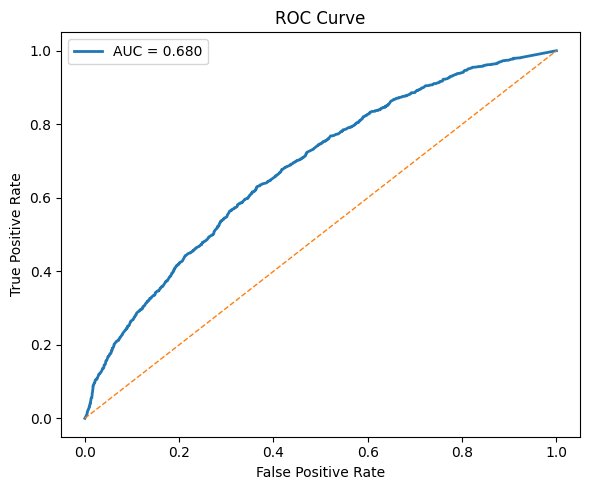

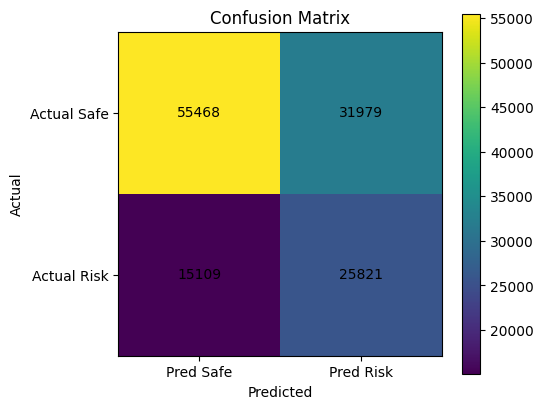

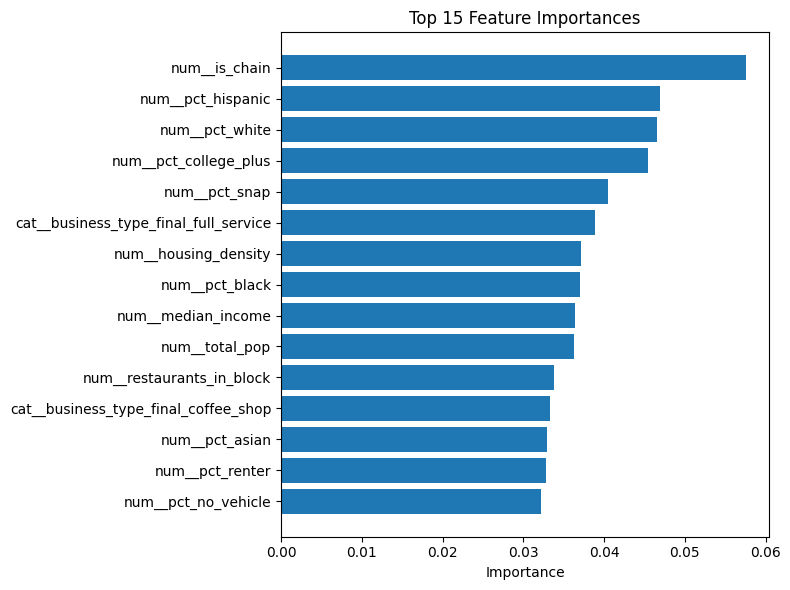

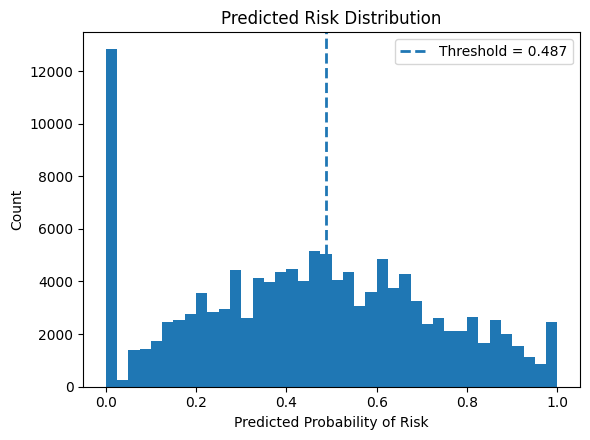

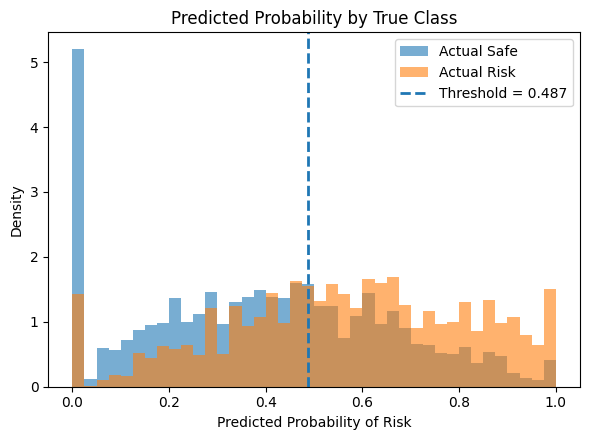

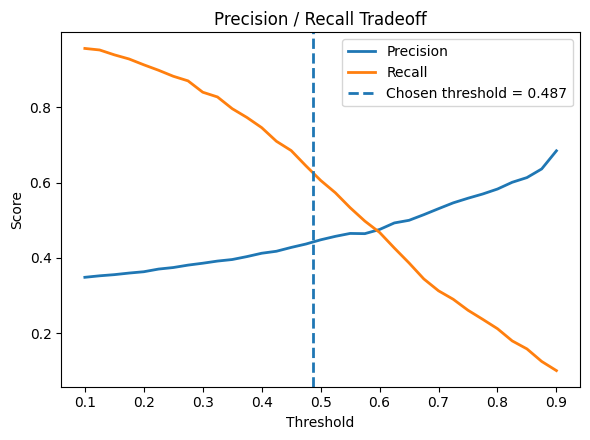

,Metric,Value
0,ROC-AUC,0.679644
1,Threshold,0.487250
2,Precision,0.446730
3,Recall,0.630858


In [24]:
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt
from sklearn .metrics import (
roc_curve ,auc ,confusion_matrix ,
precision_score ,recall_score ,roc_auc_score
)

fpr_plot ,tpr_plot ,_ =roc_curve (y_test ,probs )
roc_auc_plot =auc (fpr_plot ,tpr_plot )

plt .figure (figsize =(6 ,5 ))
plt .plot (fpr_plot ,tpr_plot ,linewidth =2 ,label =f'AUC = {roc_auc_plot:.3f}')
plt .plot ([0 ,1 ],[0 ,1 ],linestyle ='--',linewidth =1 )
plt .xlabel ('False Positive Rate')
plt .ylabel ('True Positive Rate')
plt .title ('ROC Curve')
plt .legend ()
plt .tight_layout ()
plt .show ()

cm =confusion_matrix (y_test ,preds )

plt .figure (figsize =(5.5 ,4.5 ))
plt .imshow (cm ,interpolation ='nearest')
plt .title ('Confusion Matrix')
plt .colorbar ()
tick_marks =np .arange (2 )
plt .xticks (tick_marks ,['Pred Safe','Pred Risk'])
plt .yticks (tick_marks ,['Actual Safe','Actual Risk'])
for i in range (cm .shape [0 ]):
    for j in range (cm .shape [1 ]):
        plt .text (j ,i ,format (cm [i ,j ],'d'),
        ha ='center',va ='center')
plt .ylabel ('Actual')
plt .xlabel ('Predicted')
plt .tight_layout ()
plt .show ()

top_n =15
top_importance =importance .head (top_n ).sort_values (ascending =True )

plt .figure (figsize =(8 ,6 ))
plt .barh (top_importance .index ,top_importance .values )
plt .xlabel ('Importance')
plt .title (f'Top {top_n} Feature Importances')
plt .tight_layout ()
plt .show ()

plt .figure (figsize =(6 ,4.5 ))
plt .hist (probs ,bins =40 )
plt .axvline (best_threshold ,linestyle ='--',linewidth =2 ,
label =f'Threshold = {best_threshold:.3f}')
plt .xlabel ('Predicted Probability of Risk')
plt .ylabel ('Count')
plt .title ('Predicted Risk Distribution')
plt .legend ()
plt .tight_layout ()
plt .show ()

plt .figure (figsize =(6 ,4.5 ))
plt .hist (probs [y_test ==0 ],bins =40 ,alpha =0.6 ,density =True ,label ='Actual Safe')
plt .hist (probs [y_test ==1 ],bins =40 ,alpha =0.6 ,density =True ,label ='Actual Risk')
plt .axvline (best_threshold ,linestyle ='--',linewidth =2 ,
label =f'Threshold = {best_threshold:.3f}')
plt .xlabel ('Predicted Probability of Risk')
plt .ylabel ('Density')
plt .title ('Predicted Probability by True Class')
plt .legend ()
plt .tight_layout ()
plt .show ()

grid_thresholds =np .linspace (0.10 ,0.90 ,33 )
precision_vals =[]
recall_vals =[]

for t in grid_thresholds :
    temp_preds =(probs >=t ).astype (int )
    precision_vals .append (precision_score (y_test ,temp_preds ,zero_division =0 ))
    recall_vals .append (recall_score (y_test ,temp_preds ,zero_division =0 ))

plt .figure (figsize =(6 ,4.5 ))
plt .plot (grid_thresholds ,precision_vals ,label ='Precision',linewidth =2 )
plt .plot (grid_thresholds ,recall_vals ,label ='Recall',linewidth =2 )
plt .axvline (best_threshold ,linestyle ='--',linewidth =2 ,
label =f'Chosen threshold = {best_threshold:.3f}')
plt .xlabel ('Threshold')
plt .ylabel ('Score')
plt .title ('Precision / Recall Tradeoff')
plt .legend ()
plt .tight_layout ()
plt .show ()

summary_df =pd .DataFrame ({
'Metric':['ROC-AUC','Threshold','Precision','Recall'],
'Value':[
roc_auc_score (y_test ,probs ),
best_threshold ,
precision_score (y_test ,preds ,zero_division =0 ),
recall_score (y_test ,preds ,zero_division =0 ),
]
})
display (summary_df )
